In [1]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

sns.set_style("whitegrid")

In [2]:
# Loading Iris dataset

iris=load_iris()

df=pd.DataFrame(iris.data,columns=iris.feature_names)

df["species"]=iris.target

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 150
Columns: 5


In [7]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [8]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 1


In [9]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

In [11]:
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,int64


In [12]:
original_iris=df.copy()

In [13]:
my_iris=df.copy()

In [14]:
my_iris.loc[5,"sepal length (cm)"]=np.nan
my_iris.loc[25,"petal width (cm)"]=np.nan
my_iris.loc[80,"petal length (cm)"]=np.nan

In [15]:
my_iris=pd.concat([my_iris,my_iris.iloc[[10,20]]],ignore_index=True)

In [16]:
my_iris.loc[50,"sepal length (cm)"]=20

In [17]:
my_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [18]:
print(my_iris.shape)

(152, 5)


In [19]:
my_iris.isnull().sum()

,0
sepal length (cm),1
sepal width (cm),0
petal length (cm),1
petal width (cm),1
species,0


In [20]:
print("Duplicate Rows:",my_iris.duplicated().sum())

Duplicate Rows: 3


In [21]:
my_iris.to_csv("my_iris.csv",index=False)

In [22]:
clean_iris=my_iris.copy()

In [23]:
clean_iris.isnull().sum()

,0
sepal length (cm),1
sepal width (cm),0
petal length (cm),1
petal width (cm),1
species,0


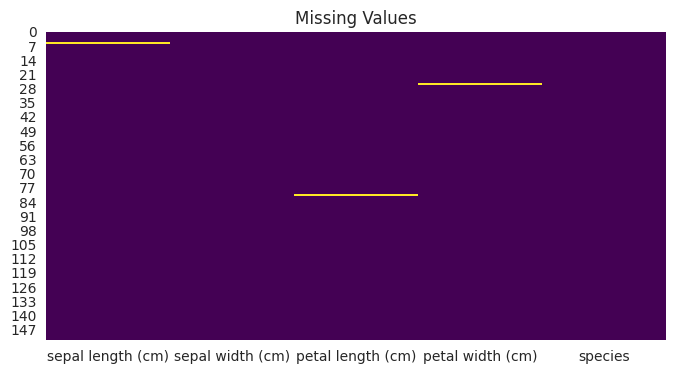

In [24]:
plt.figure(figsize=(8,4))
sns.heatmap(clean_iris.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values")
plt.show()

In [25]:
numeric_columns=clean_iris.select_dtypes(include=np.number).columns

for column in numeric_columns:
    clean_iris[column].fillna(clean_iris[column].mean(),inplace=True)

/tmp/ipykernel_1944/3890953911.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_iris[column].fillna(clean_iris[column].mean(),inplace=True)


In [26]:
clean_iris.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [27]:
print(clean_iris.duplicated().sum())

3


In [28]:
clean_iris=clean_iris.drop_duplicates()

In [29]:
print(clean_iris.duplicated().sum())

0


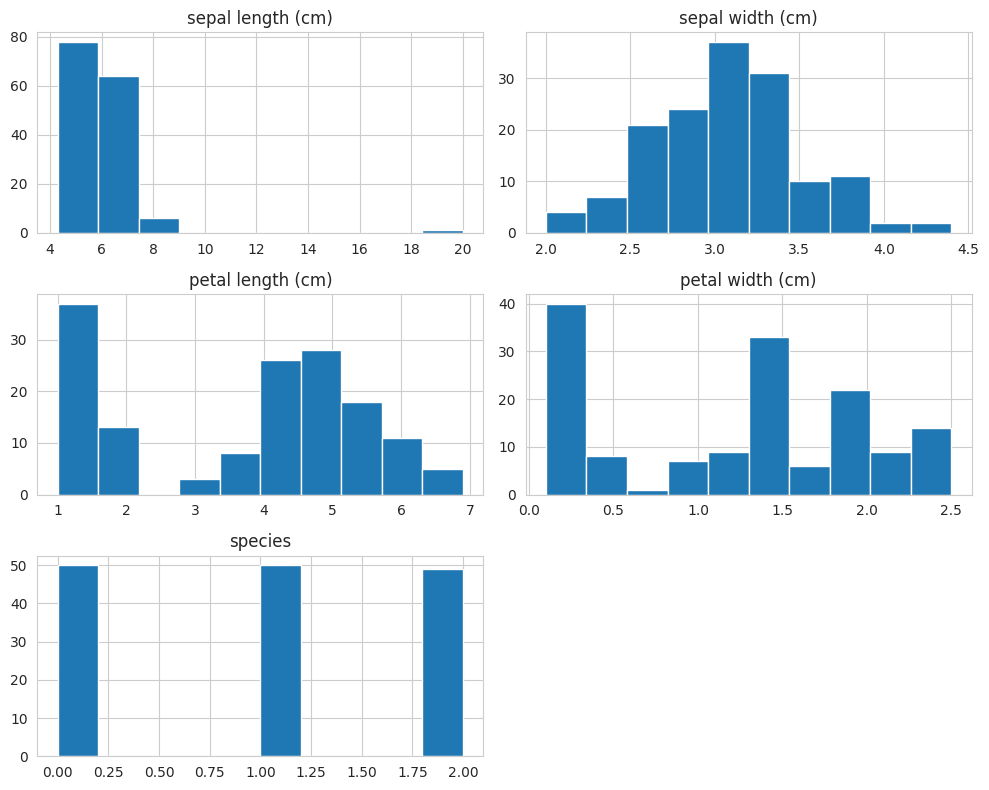

In [30]:
clean_iris.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

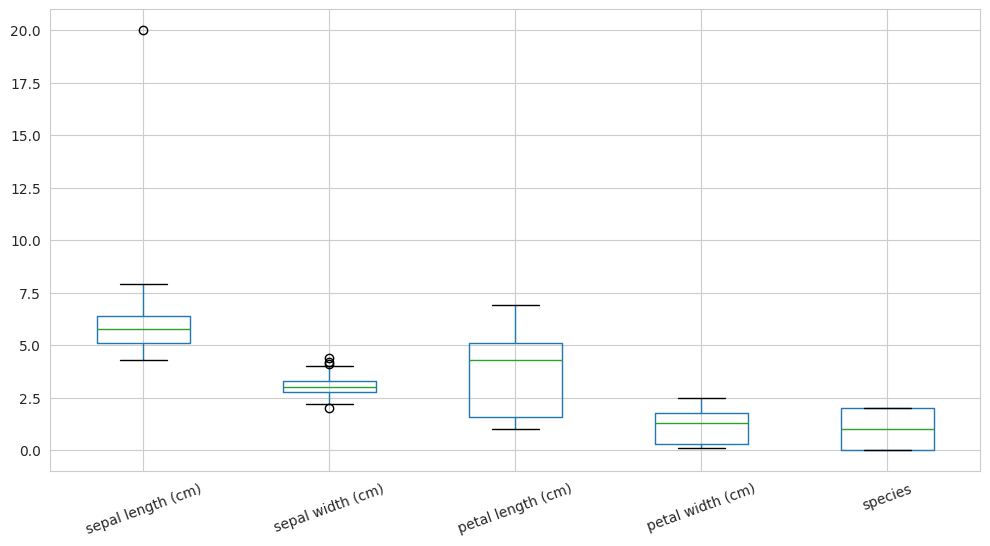

In [31]:
plt.figure(figsize=(12,6))

clean_iris.boxplot()

plt.xticks(rotation=20)
plt.show()

In [32]:
for column in clean_iris.columns[:-1]:

    q1=clean_iris[column].quantile(0.25)
    q3=clean_iris[column].quantile(0.75)

    iqr=q3-q1

    lower=q1-1.5*iqr
    upper=q3+1.5*iqr

    clean_iris=clean_iris[(clean_iris[column]>=lower)&(clean_iris[column]<=upper)]

In [33]:
clean_iris.shape

(145, 5)

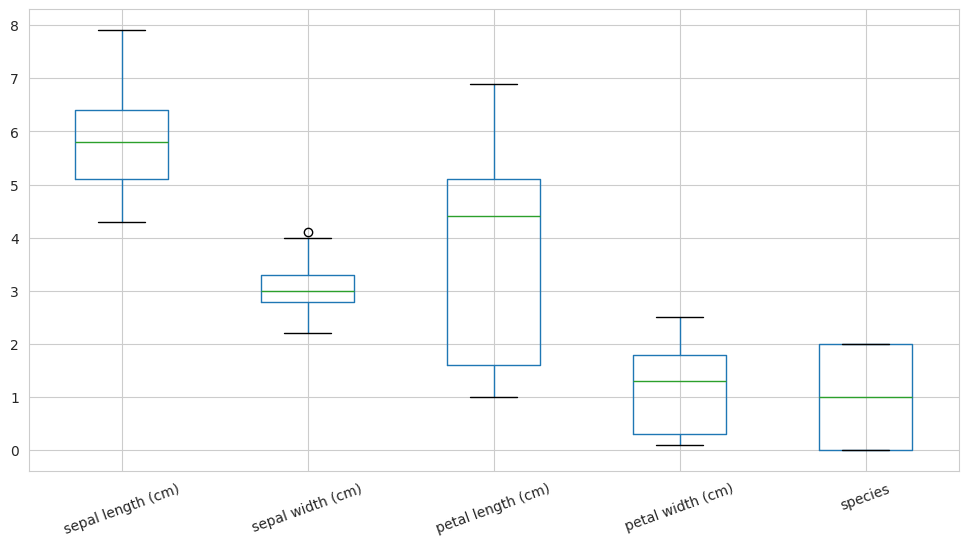

In [34]:
plt.figure(figsize=(12,6))

clean_iris.boxplot()

plt.xticks(rotation=20)
plt.show()

In [35]:
correlation=clean_iris.corr()

correlation

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
sepal length (cm),1.000000,-0.130178,0.878884,0.820584,0.794120
sepal width (cm),-0.130178,1.000000,-0.416473,-0.356954,-0.412065
petal length (cm),0.878884,-0.416473,1.000000,0.957166,0.949335
petal width (cm),0.820584,-0.356954,0.957166,1.000000,0.950945
species,0.794120,-0.412065,0.949335,0.950945,1.000000


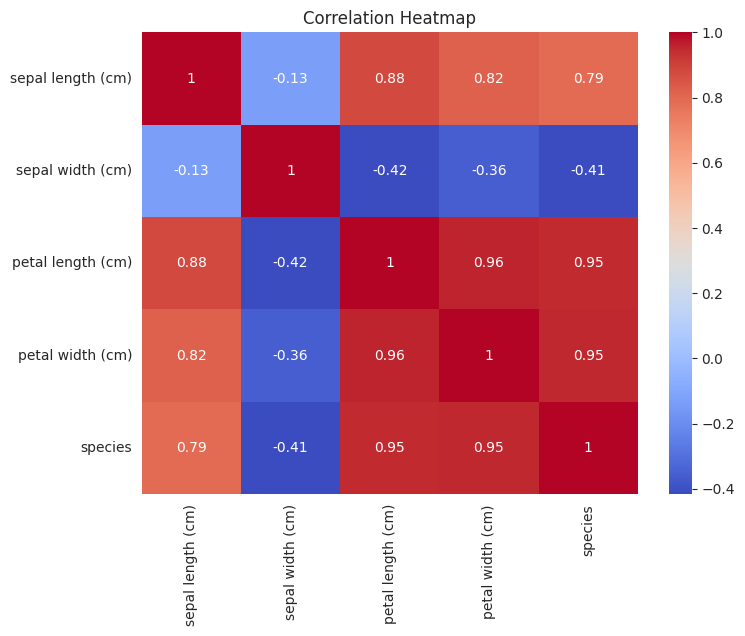

In [36]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation,annot=True,cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

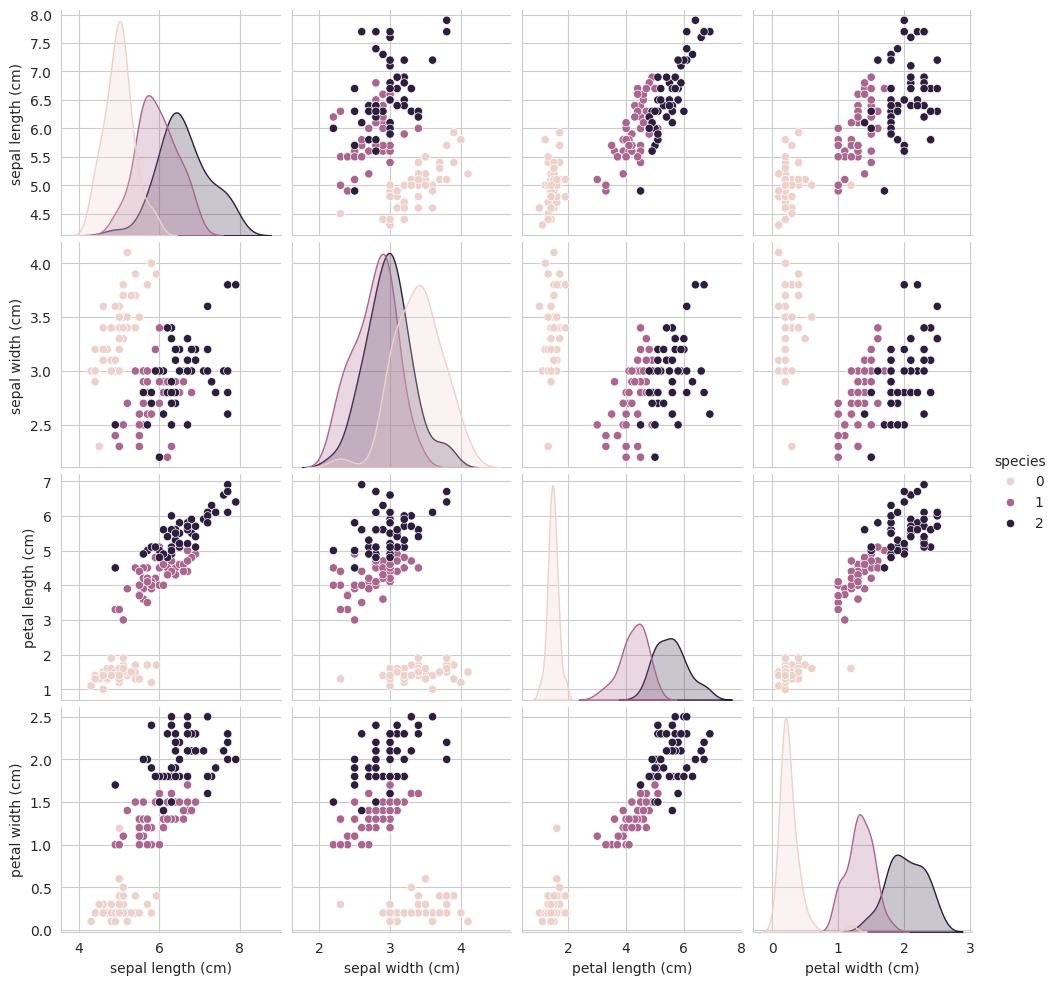

In [37]:
sns.pairplot(clean_iris,hue="species")

plt.show()

In [38]:
correlation

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
sepal length (cm),1.000000,-0.130178,0.878884,0.820584,0.794120
sepal width (cm),-0.130178,1.000000,-0.416473,-0.356954,-0.412065
petal length (cm),0.878884,-0.416473,1.000000,0.957166,0.949335
petal width (cm),0.820584,-0.356954,0.957166,1.000000,0.950945
species,0.794120,-0.412065,0.949335,0.950945,1.000000


In [39]:
clean_iris=clean_iris.drop(columns=["petal width (cm)"])

In [40]:
clean_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),species
0,5.1,3.5,1.4,0
1,4.9,3.0,1.4,0
2,4.7,3.2,1.3,0
3,4.6,3.1,1.5,0
4,5.0,3.6,1.4,0


In [41]:
clean_iris.shape

(145, 4)

In [42]:
clean_iris.to_csv("clean_iris.csv",index=False)

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [44]:
X=original_iris.drop(columns=["petal length (cm)"])
X=X.drop(columns=["species"])

y=original_iris["petal length (cm)"]

In [45]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
model1=LinearRegression()

model1.fit(X_train,y_train)

LinearRegression()

In [47]:
prediction1=model1.predict(X_test)

In [48]:
mae1=mean_absolute_error(y_test,prediction1)

mse1=mean_squared_error(y_test,prediction1)

rmse1=np.sqrt(mse1)

r21=r2_score(y_test,prediction1)

In [49]:
print("Original Iris Results")
print("MAE:",mae1)
print("MSE:",mse1)
print("RMSE:",rmse1)
print("R2 Score:",r21)

Original Iris Results
MAE: 0.2605179846252386
MSE: 0.13001626031382688
RMSE: 0.3605776758395157
R2 Score: 0.9603293155857664


In [50]:
X=my_iris.drop(columns=["petal length (cm)"])
X=X.drop(columns=["species"])

y=my_iris["petal length (cm)"]

In [51]:
X=X.fillna(X.mean())

y=y.fillna(y.mean())

In [52]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [53]:
model2=LinearRegression()

model2.fit(X_train,y_train)

LinearRegression()

In [54]:
prediction2=model2.predict(X_test)

In [55]:
mae2=mean_absolute_error(y_test,prediction2)

mse2=mean_squared_error(y_test,prediction2)

rmse2=np.sqrt(mse2)

r22=r2_score(y_test,prediction2)

In [56]:
print("My Iris Results")
print("MAE:",mae2)
print("MSE:",mse2)
print("RMSE:",rmse2)
print("R2 Score:",r22)

My Iris Results
MAE: 0.2639262649958724
MSE: 0.13187050343598988
RMSE: 0.3631397849809215
R2 Score: 0.9522636665730029


In [57]:
X=clean_iris.drop(columns=["petal length (cm)"])

if "species" in X.columns:
    X=X.drop(columns=["species"])

y=clean_iris["petal length (cm)"]

In [58]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [59]:
model3=LinearRegression()

model3.fit(X_train,y_train)

LinearRegression()

In [60]:
prediction3=model3.predict(X_test)

In [61]:
mae3=mean_absolute_error(y_test,prediction3)

mse3=mean_squared_error(y_test,prediction3)

rmse3=np.sqrt(mse3)

r23=r2_score(y_test,prediction3)

In [62]:
print("Clean Iris Results")
print("MAE:",mae3)
print("MSE:",mse3)
print("RMSE:",rmse3)
print("R2 Score:",r23)

Clean Iris Results
MAE: 0.4898603863288244
MSE: 0.341029754092352
RMSE: 0.5839775287563315
R2 Score: 0.8895179277567747


In [63]:
results=pd.DataFrame({
    "Actual":y_test,
    "Predicted":prediction3
})

results.head(10)

,Actual,Predicted
73,4.7,4.550059
145,5.2,5.347067
28,1.4,2.114012
20,1.7,2.471573
44,1.9,1.383883
121,4.9,3.656156
130,6.1,6.874204
112,5.5,5.525848
88,4.1,3.380482
19,1.5,1.383883


In [64]:
# Creating comparison table

comparison=pd.DataFrame({
    "Dataset":["Original Iris","My Iris","Clean Iris"],
    "MAE":[mae1,mae2,mae3],
    "MSE":[mse1,mse2,mse3],
    "RMSE":[rmse1,rmse2,rmse3],
    "R2 Score":[r21,r22,r23]
})

comparison

,Dataset,MAE,MSE,RMSE,R2 Score
0,Original Iris,0.260518,0.130016,0.360578,0.960329
1,My Iris,0.263926,0.131871,0.363140,0.952264
2,Clean Iris,0.489860,0.341030,0.583978,0.889518


In [65]:
comparison.to_csv("comparison_results.csv",index=False)

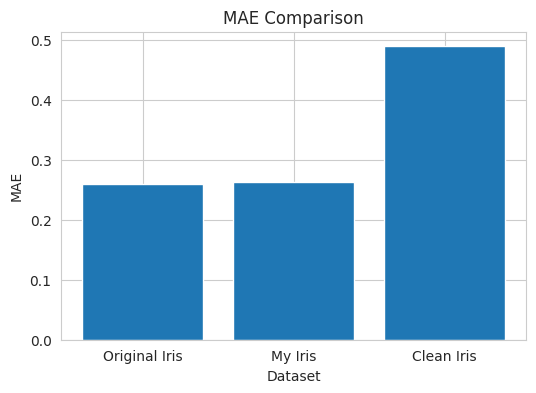

In [66]:
# MAE Comparison

plt.figure(figsize=(6,4))

plt.bar(comparison["Dataset"],comparison["MAE"])

plt.title("MAE Comparison")
plt.xlabel("Dataset")
plt.ylabel("MAE")

plt.show()

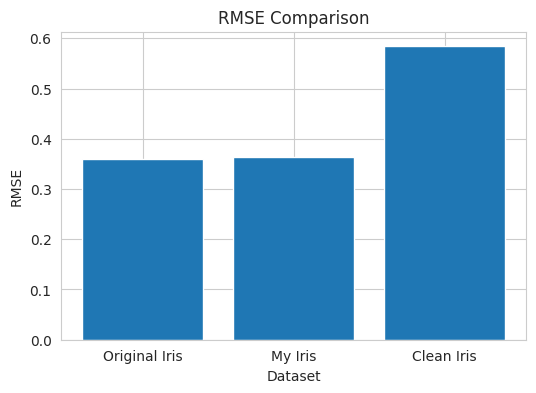

In [67]:
# RMSE Comparison

plt.figure(figsize=(6,4))

plt.bar(comparison["Dataset"],comparison["RMSE"])

plt.title("RMSE Comparison")
plt.xlabel("Dataset")
plt.ylabel("RMSE")

plt.show()

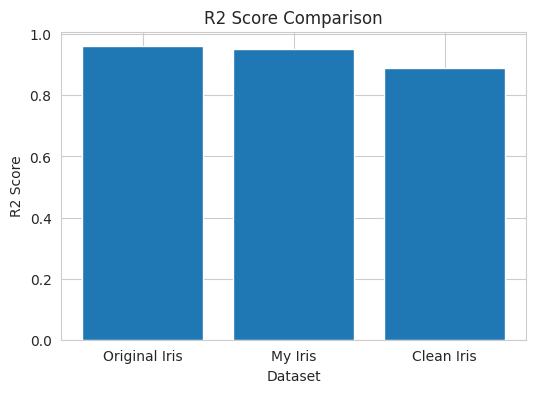

In [68]:
# R2 Score Comparison

plt.figure(figsize=(6,4))

plt.bar(comparison["Dataset"],comparison["R2 Score"])

plt.title("R2 Score Comparison")
plt.xlabel("Dataset")
plt.ylabel("R2 Score")

plt.show()

In [70]:
# Displaying complete comparison

print(comparison)

         Dataset       MAE       MSE      RMSE  R2 Score
0  Original Iris  0.260518  0.130016  0.360578  0.960329
1        My Iris  0.263926  0.131871  0.363140  0.952264
2     Clean Iris  0.489860  0.341030  0.583978  0.889518


# Report

## Objective

The objective of this lab was to perform data wrangling on the Iris dataset, visualize the preprocessing steps, apply a Linear Regression model, and compare the performance of different datasets.

## Data Wrangling

The following preprocessing techniques were applied:

- Checked dataset dimensions and data types.
- Checked for missing values.
- Introduced missing values in the modified dataset for demonstration.
- Filled missing values using the mean of each numerical column.
- Checked and removed duplicate rows.
- Detected outliers using boxplots and removed them using the IQR method.
- Examined feature relationships using a correlation heatmap.
- Removed redundant features when necessary.

## Visualization

The following visualizations were generated:

- Missing value heatmap
- Histograms
- Boxplots
- Correlation heatmap
- Pairplot
- Performance comparison bar charts

These visualizations helped understand the quality of the data and justified each preprocessing step.

## Model Training

Linear Regression was applied on:

1. Original Iris Dataset
2. Modified (My Iris) Dataset
3. Cleaned Iris Dataset

The datasets were divided into:

- Training Data: 80%
- Testing Data: 20%

## Evaluation Metrics

The following evaluation metrics were used:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

## Results

The comparison table shows the performance of each dataset.

Generally, the cleaned dataset produced lower error values and a higher R² score, indicating better prediction performance after preprocessing.

## Conclusion

Data preprocessing plays an important role in machine learning. Handling missing values, removing duplicates, eliminating outliers, and reducing redundant information improved the overall quality of the dataset. As a result, the Linear Regression model achieved better predictive performance on the cleaned dataset compared to the original and modified datasets.

In [71]:
# Saving cleaned dataset

clean_iris.to_csv("clean_iris.csv",index=False)

# Saving comparison table

comparison.to_csv("comparison_results.csv",index=False)

print("Files Saved Successfully")

Files Saved Successfully
